## Task 2b: Identifying Market Insight

---
## 0. Import and Configuration

In [17]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from apyori import apriori
from collections import Counter

#paths
base_path    = r'C:\Users\MiniPC\Documents\Data mining\a1'
data_path    = os.path.join(base_path, 'datas')
sampled_path = os.path.join(base_path, 'sampled_datas')
output_path = os.path.join(base_path, 'timing_datas')

PRODUCTS_PATH          = os.path.join(data_path,    'products.csv')
AISLES_PATH            = os.path.join(data_path,    'aisles.csv')
TRANSACTIONS_JSON_PATH = os.path.join(sampled_path, 'transactions_sampled.json')
SAMPLED_ORDERS_PATH    = os.path.join(sampled_path, 'order_products_sampled.csv')
ORDERS_PATH            = os.path.join(data_path,    'orders.csv')

print('Imports done')

Imports done


---
## 1.Load datas

In [18]:
#load needed data
products = pd.read_csv(PRODUCTS_PATH)
aisles   = pd.read_csv(AISLES_PATH)
orders   = pd.read_csv(ORDERS_PATH)
op_sampled = pd.read_csv(SAMPLED_ORDERS_PATH)

id_to_name  = products.set_index('product_id')['product_name'].to_dict()
id_to_aisle = products.set_index('product_id')['aisle_id'].to_dict()
aisle_to_name = aisles.set_index('aisle_id')['aisle'].to_dict()

with open(TRANSACTIONS_JSON_PATH, 'r') as f:
    transactions_ids = json.load(f)

print(f'Products:     {len(products):,}')
print(f'Orders:       {len(orders):,}')
print(f'Transactions: {len(transactions_ids):,}')

Products:     49,688
Orders:       3,421,083
Transactions: 146,776


---
## Part 1 : Product Categories
### 1. Build aisle-level transaction

In [19]:
# Going from specific product to categories (aisles)
transactions_aisle = [
    list(set(  
        aisle_to_name.get(id_to_aisle.get(int(pid)), 'unknown')
        for pid in transaction
    ))
    for transaction in transactions_ids
]

# Remove transactions with only 1 aisle
transactions_aisle = [t for t in transactions_aisle if len(t) > 1]

print(f'Aisle transactions: {len(transactions_aisle):,}')
print(f'Example: {transactions_aisle[0]}')

Aisle transactions: 137,659
Example: ['refrigerated', 'soap', 'oils vinegars', 'cookies cakes', 'packaged cheese', 'frozen meals', 'coffee', 'refrigerated pudding desserts', 'ice cream ice']


---
## 2. Rebuild function

In [20]:
def parse_apyori_results(results):
    """
    Flattens Apyori output into a structured Pandas DataFrame.
    Calculates support, confidence, and lift for each association.
    """
    rows = []
    for result in results:
        support = result.support
        items = list(result.items)
        for stat in result.ordered_statistics:
            antecedent = list(stat.items_base)
            consequent = list(stat.items_add)
            if not antecedent or not consequent:  
                continue
            rows.append({
                'antecedent': ', '.join(antecedent),
                'consequent': ', '.join(consequent),
                'support':    round(support, 4),
                'confidence': round(stat.confidence, 4),
                'lift':       round(stat.lift, 4),
                'len_ant': len(antecedent),
                'len_con': len(consequent),
                "len_total": len(set(antecedent).union(consequent)),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame(columns=[
            "antecedent","consequent","support","confidence","lift",
            "len_ant","len_con","len_total"
        ])
    return df.sort_values(["lift", "confidence", "support"], ascending=False).reset_index(drop=True)


In [21]:
#mining association at category level
results_aisle = list(apriori(
    transactions_aisle,
    min_support=0.05,
    min_confidence=0.3,
    min_lift=1.5,
    max_length=3
))

#convert to readable format
df_aisle = parse_apyori_results(results_aisle)
display(df_aisle.head(15))

,antecedent,consequent,support,confidence,lift,len_ant,len_con,len_total
0,fresh herbs,"packaged vegetables fruits, fresh vegetables",0.0501,0.5050,2.0233,1,2,3
1,fresh herbs,"fresh vegetables, fresh fruits",0.0660,0.6652,1.9716,1,2,3
2,"packaged vegetables fruits, fresh herbs",fresh vegetables,0.0501,0.8910,1.9027,2,1,3
3,"fresh herbs, fresh fruits",fresh vegetables,0.0660,0.8814,1.8821,2,1,3
4,fresh herbs,fresh vegetables,0.0841,0.8476,1.8098,1,1,2
5,"milk, packaged vegetables fruits",yogurt,0.0549,0.4762,1.7022,2,1,3
6,canned jarred vegetables,fresh vegetables,0.0600,0.7696,1.6435,1,1,2
7,"frozen produce, fresh vegetables",packaged vegetables fruits,0.0535,0.6356,1.6348,2,1,3
8,"packaged vegetables fruits, yogurt",packaged cheese,0.0546,0.3968,1.6299,2,1,3
9,"milk, fresh vegetables",packaged cheese,0.0525,0.3962,1.6273,2,1,3


---
## 3. We reuse the best product-level from Task 2a

In [22]:
#display
df_products = pd.read_csv(os.path.join(sampled_path, 'rules_exp1_low.csv'))

print('Top 10 product rules by lift:')
display(df_products[['antecedent','consequent','support','confidence','lift']].head(10))

Top 10 product rules by lift:


,antecedent,consequent,support,confidence,lift
0,Organic Cilantro,Limes,0.0069,0.2680,5.1587
1,Limes,Organic Cilantro,0.0069,0.1322,5.1587
2,Organic Garlic,Organic Yellow Onion,0.0080,0.2069,5.0961
3,Organic Yellow Onion,Organic Garlic,0.0080,0.1962,5.0961
4,Limes,Large Lemon,0.0105,0.2025,3.6498
5,Large Lemon,Limes,0.0105,0.1896,3.6498
6,"Organic Strawberries, Bag of Organic Bananas",Organic Hass Avocado,0.0056,0.2512,3.2614
7,Organic Lemon,Organic Hass Avocado,0.0075,0.2389,3.1011
8,Organic Garlic,Limes,0.0059,0.1520,2.9258
9,Limes,Organic Garlic,0.0059,0.1127,2.9258


---
## Part 2 - Purchase Timing

## 1. Merge sampled orders with timing datas

In [23]:
#addition of timing infos to sampled orders
orders_time = orders[["order_id", "order_dow", "order_hour_of_day"]]

op_time = op_sampled.merge(
    orders_time,
    on="order_id",
    how="left"
)

print(op_time.head())
print(op_time[["order_id", "order_dow", "order_hour_of_day"]].isna().sum())

   order_id  product_id  add_to_cart_order  reordered  order_dow  \
0        33        5699                  1          1          1   
1        33       32740                  2          0          1   
2        33        8592                  3          0          1   
3        33        1446                  4          0          1   
4        33       46313                  5          0          1   

   order_hour_of_day  
0                 18  
1                 18  
2                 18  
3                 18  
4                 18  
order_id             0
order_dow            0
order_hour_of_day    0
dtype: int64


---
## 2. Function to create hour categories

In [24]:
#discretizing time data into categories, easier to reuse
def hour_to_period(h):
    if h < 11:
        return "HOUR_MORNING"
    elif h < 17:
        return "HOUR_AFTERNOON"
    else:
        return "HOUR_EVENING"

# map into days of the week
dow_map = {
    0: "DOW_Sunday",
    1: "DOW_Monday",
    2: "DOW_Tuesday",
    3: "DOW_Wednesday",
    4: "DOW_Thursday",
    5: "DOW_Friday",
    6: "DOW_Saturday"
}

op_time["dow_token"] = op_time["order_dow"].map(dow_map)
op_time["hour_period"] = op_time["order_hour_of_day"].apply(hour_to_period)

---
## 3. Add transaction to transaction

In [25]:
#construct hybrid transaction (aisles + temporal datas)
transactions_timing = []

for order_id, group in op_time.groupby("order_id"):
    aisle_items = list(set(
        aisle_to_name.get(id_to_aisle.get(int(pid)), "unknown")
        for pid in group["product_id"]
    ))
    
    dow_item = group["dow_token"].iloc[0]
    hour_item = group["hour_period"].iloc[0]
    
    transaction = aisle_items + [dow_item, hour_item]
    transactions_timing.append(transaction)

print(f"Timing transactions: {len(transactions_timing):,}")
print("Example:", transactions_timing[0])

Timing transactions: 146,776
Example: ['refrigerated', 'soap', 'oils vinegars', 'cookies cakes', 'packaged cheese', 'frozen meals', 'coffee', 'refrigerated pudding desserts', 'ice cream ice', 'DOW_Monday', 'HOUR_EVENING']


---
## 4.Run Apriori

In [26]:
# Running Apriori on hybrid transactions --> find correlations time & product
results_timing = list(apriori(
    transactions_timing,
    min_support=0.02,
    min_confidence=0.2,
    min_lift=1.1,
    max_length=3
))

df_timing = parse_apyori_results(results_timing)
print(f"Timing rules generated: {len(df_timing):,}")
display(df_timing.head(20))

Timing rules generated: 1,763


,antecedent,consequent,support,confidence,lift,len_ant,len_con,len_total
0,fresh dips tapenades,"fresh fruits, chips pretzels",0.0242,0.2460,2.3684,1,2,3
1,"fresh fruits, chips pretzels",fresh dips tapenades,0.0242,0.2334,2.3684,2,1,3
2,dry pasta,"fresh vegetables, packaged cheese",0.0221,0.3119,2.3177,1,2,3
3,canned jarred vegetables,"fresh vegetables, packaged cheese",0.0224,0.3058,2.2724,1,2,3
4,canned meals beans,"fresh vegetables, packaged cheese",0.0204,0.2916,2.1672,1,2,3
5,lunch meat,"fresh fruits, bread",0.0248,0.2396,2.1558,1,2,3
6,"fresh fruits, bread",lunch meat,0.0248,0.2236,2.1558,2,1,3
7,fresh herbs,"packaged vegetables fruits, fresh vegetables",0.0470,0.5040,2.1527,1,2,3
8,"packaged vegetables fruits, fresh vegetables",fresh herbs,0.0470,0.2008,2.1527,2,1,3
9,"packaged vegetables fruits, other creams cheeses",packaged cheese,0.0203,0.4934,2.1519,2,1,3


---
## 5. Keep only related to time rules

In [27]:
# Extracting only 'Temporal Rules'
df_timing_only = df_timing[
    df_timing["antecedent"].str.contains("DOW_|HOUR_") |
    df_timing["consequent"].str.contains("DOW_|HOUR_")
].copy()

display(df_timing_only.head(20))

,antecedent,consequent,support,confidence,lift,len_ant,len_con,len_total
48,fresh herbs,"fresh vegetables, HOUR_AFTERNOON",0.0405,0.4343,1.9616,1,2,3
49,fresh herbs,"HOUR_MORNING, fresh vegetables",0.0208,0.2230,1.9615,1,2,3
56,"HOUR_MORNING, fresh herbs",fresh vegetables,0.0208,0.8547,1.9320,2,1,3
61,"fresh herbs, HOUR_AFTERNOON",fresh vegetables,0.0405,0.8453,1.9109,2,1,3
68,"lunch meat, HOUR_AFTERNOON",packaged cheese,0.0222,0.4329,1.8880,2,1,3
73,lunch meat,"packaged cheese, HOUR_AFTERNOON",0.0222,0.2143,1.8672,1,2,3
153,canned jarred vegetables,"fresh vegetables, HOUR_AFTERNOON",0.0286,0.3895,1.7590,1,2,3
170,"canned jarred vegetables, HOUR_AFTERNOON",fresh vegetables,0.0286,0.7697,1.7399,2,1,3
276,canned meals beans,"fresh vegetables, HOUR_AFTERNOON",0.0258,0.3679,1.6617,1,2,3
322,"crackers, HOUR_AFTERNOON",packaged cheese,0.0213,0.3739,1.6307,2,1,3


---
## 6. Focus on interpretable rules

In [28]:
# keep results that can be investigated (strong association)
df_timing_simple = df_timing_only[
    (df_timing_only["len_ant"] == 1) &
    (df_timing_only["len_con"] == 1)
].copy()

df_timing_simple = df_timing_simple.sort_values(
    ["support", "confidence", "lift"],
    ascending=False
)

display(df_timing_simple.head(15))

,antecedent,consequent,support,confidence,lift,len_ant,len_con,len_total
1547,DOW_Sunday,fresh vegetables,0.0933,0.5341,1.2074,1,1,2
1548,fresh vegetables,DOW_Sunday,0.0933,0.2110,1.2074,1,1,2
1629,DOW_Sunday,packaged vegetables fruits,0.0754,0.4315,1.1765,1,1,2
1630,packaged vegetables fruits,DOW_Sunday,0.0754,0.2056,1.1765,1,1,2
1725,DOW_Saturday,fresh vegetables,0.0647,0.4959,1.1210,1,1,2
1698,DOW_Sunday,yogurt,0.0527,0.3017,1.1425,1,1,2
1741,DOW_Monday,HOUR_MORNING,0.0509,0.2966,1.1097,1,1,2
1702,DOW_Sunday,packaged cheese,0.0456,0.2612,1.1393,1,1,2
1750,DOW_Thursday,HOUR_EVENING,0.0338,0.2691,1.1053,1,1,2
1758,DOW_Saturday,packaged cheese,0.0330,0.2529,1.1029,1,1,2


---
## 7. Save timing rules

In [30]:
# save timing rules data
df_timing.to_csv(os.path.join(output_path, "rules_timing_all.csv"), index=False)
df_timing_only.to_csv(os.path.join(output_path, "rules_timing_only.csv"), index=False)
df_timing_simple.to_csv(os.path.join(output_path, "rules_timing_simple.csv"), index=False)
df_aisle.to_csv(os.path.join(output_path, 'rules_aisle.csv'), index=False)
df_timing_only.to_csv(os.path.join(output_path, 'rules_timing.csv'), index=False)

print("Timing rules saved")

Timing rules saved


---
## 8. Final vizualisation

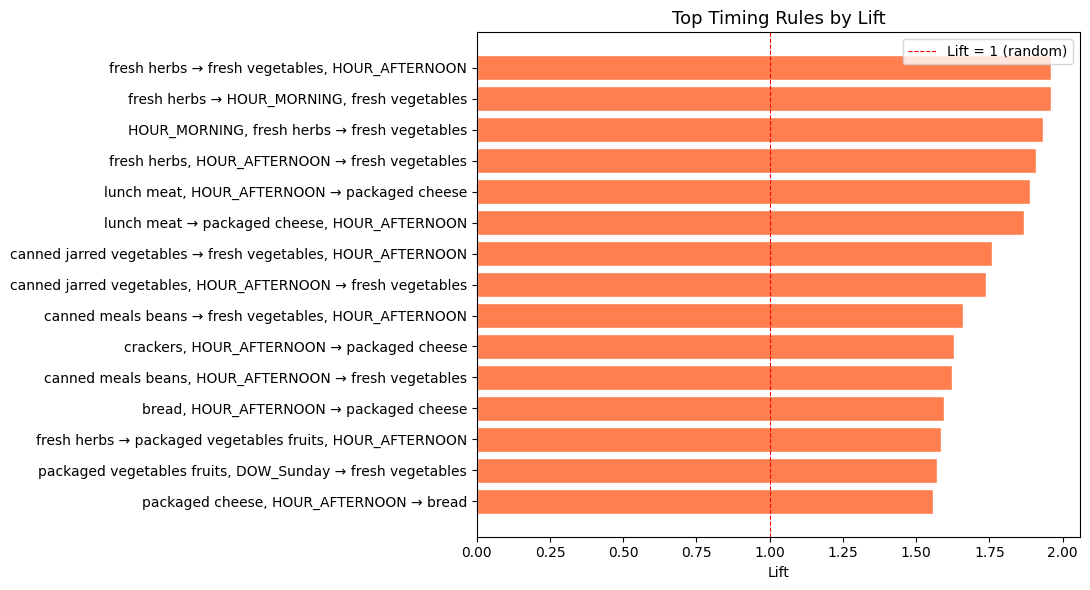

In [31]:
top_timing = df_timing_only.head(15)

fig, ax = plt.subplots(figsize=(11, 6))
labels = top_timing['antecedent'] + ' → ' + top_timing['consequent']
ax.barh(labels[::-1], top_timing['lift'][::-1], color='coral', edgecolor='white')
ax.set_xlabel('Lift')
ax.set_title('Top Timing Rules by Lift', fontsize=13)
ax.axvline(x=1, color='red', linestyle='--', linewidth=0.8, label='Lift = 1 (random)')
ax.legend()
plt.tight_layout()
plt.show()